Part 1 : Understanding and Exploration

1. Load Dataset

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:

df = pd.read_csv("/content/healthcare_dataset.csv")
df.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


2. Explore dataset

In [29]:
# a. shape
df.shape

(6000, 7)

In [30]:

# b. Column types
df.dtypes

,0
patient_id,int64
age,int64
bmi,float64
exercise_hours_per_week,float64
smoker,int64
blood_pressure,float64
diabetes,int64


In [31]:
# c. Missing values
df.isnull().sum()


,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


3. Statistical Analysis

In [32]:




df.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


4.Data Visualization

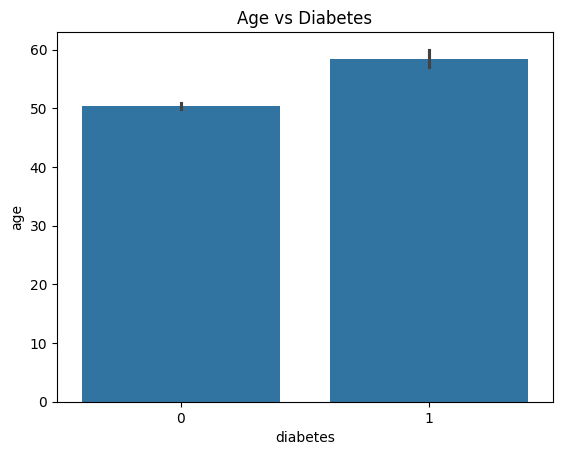

In [33]:

# Age vs Diabetes
sns.barplot(x="diabetes", y="age", data=df)
plt.title("Age vs Diabetes")
plt.show()

Individuals with diabetes have a higher average age compared to non-diabetic individuals, suggesting that the likelihood of diabetes increases with age.


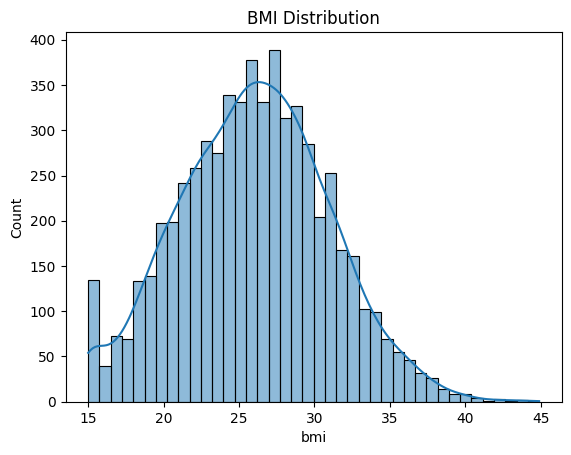

In [34]:

# BMI distribution
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.show()

Most individuals have a BMI between 25 and 30, indicating an overweight population. Higher BMI is
 associated with increased risk of diabetes.

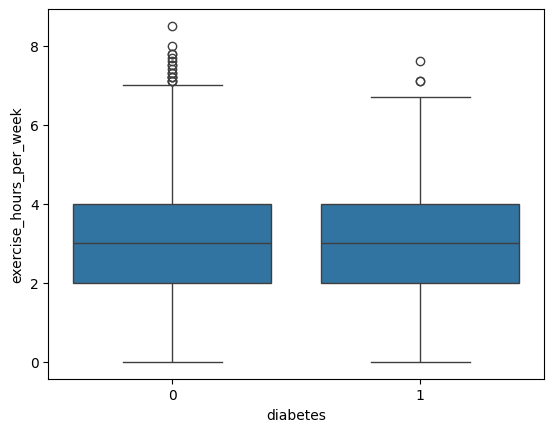

In [35]:


# Exercise vs Diabetes
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=df)
plt.show()

The distribution of exercise hours is very similar for both diabetic and non-diabetic individuals, suggesting that exercise hours alone may not strongly differentiate diabetes cases in this dataset.

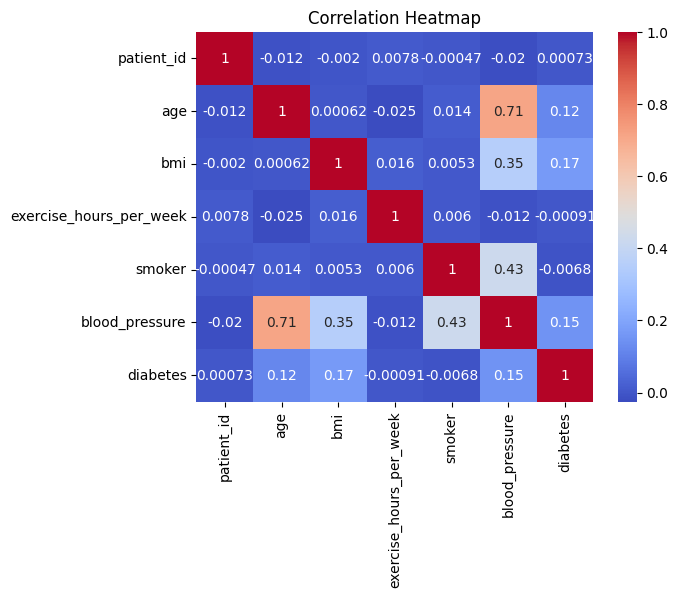

In [36]:
# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows that age and blood pressure have the strongest positive correlation (0.71), indicating that blood pressure tends to increase with age. Smoker and blood pressure also show a moderate relationship, which may influence diabetes risk.

Part 2: Machine Learning Classification Model

In [37]:

# 1. Prepare Data
X = df.drop(['patient_id', 'diabetes'], axis=1)
y = df['diabetes']

In [38]:
# 2. Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2)

In [39]:
# Handle class imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [40]:
# 3. Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
# 4. Train Model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [42]:
# 5. Prediction
y_pred = model.predict(X_test)

In [43]:
# 6. Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6533333333333333
Confusion Matrix:
 [[716 376]
 [ 40  68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.66      0.77      1092
           1       0.15      0.63      0.25       108

    accuracy                           0.65      1200
   macro avg       0.55      0.64      0.51      1200
weighted avg       0.88      0.65      0.73      1200



In [44]:
# Feature Importance

coefficients = pd.DataFrame(model.coef_[0], X.columns, columns=['Coefficient'])
print(coefficients)

                         Coefficient
age                         0.000556
bmi                         0.437111
exercise_hours_per_week     0.007643
smoker                     -0.593564
blood_pressure              0.660961


Part 3 — Neural Network Model (TensorFlow/Keras)

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [46]:
# Build Neural Network Model
nn_model = keras.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],), name='input_layer'),
        layers.Dense(32, activation='relu', name='hidden_layer_1'),
        layers.Dense(16, activation='relu', name='hidden_layer_2'),
        layers.Dense(1, activation='sigmoid', name='output_layer')
    ]
)

# Display model architecture
nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# 2. Compile Model

nn_model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(name='binary_cross_entopy'),
    metrics=[
        keras.metrics.BinaryAccuracy(name='Accuracy'),
        keras.metrics.MeanSquaredError(name='MSE')
    ]
)

In [48]:
# 3. Train Model
history = nn_model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.6468 - MSE: 0.2172 - loss: 0.6222 - val_Accuracy: 0.6567 - val_MSE: 0.1980 - val_loss: 0.5725
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.6785 - MSE: 0.2041 - loss: 0.5921 - val_Accuracy: 0.6475 - val_MSE: 0.1996 - val_loss: 0.5756
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Accuracy: 0.6812 - MSE: 0.2014 - loss: 0.5860 - val_Accuracy: 0.6150 - val_MSE: 0.2168 - val_loss: 0.6133
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Accuracy: 0.6798 - MSE: 0.1994 - loss: 0.5812 - val_Accuracy: 0.6192 - val_MSE: 0.2184 - val_loss: 0.6180
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.6875 - MSE: 0.1981 - loss: 0.5784 - val_Accuracy: 0.6333 - val_MSE: 0.2101 - val_loss: 0.5979
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.6915 - MSE: 0.1969 - loss: 0.5754 - val_Accuracy: 0.5875 - val_MSE: 0.2346 - val_loss: 0.6553
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 

In [49]:
# Evaluate Model
loss, accuracy, mse = nn_model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Test MSE:", mse)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.6292 - MSE: 0.2157 - loss: 0.6110 
Test Loss: 0.610990047454834
Test Accuracy: 0.6291666626930237
Test MSE: 0.21568697690963745


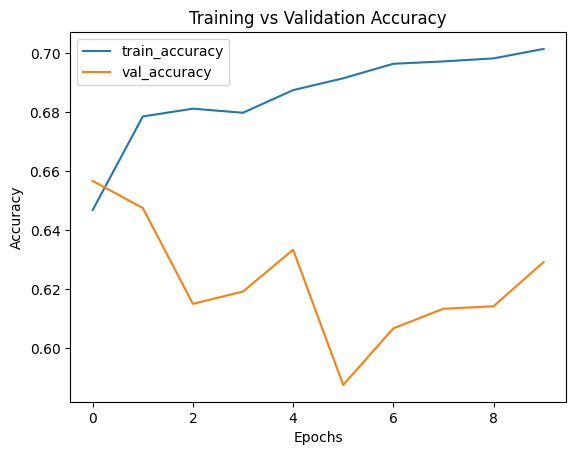

In [50]:
import matplotlib.pyplot as plt

# Training Visualization
plt.plot(history.history['Accuracy'], label='train_accuracy')
plt.plot(history.history['val_Accuracy'], label='val_accuracy')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

In [51]:

# Neural Network accuracy
nn_accuracy = accuracy

print("Logistic Regression Accuracy:", lr_accuracy)
print("Neural Network Accuracy:", nn_accuracy)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Neural Network"],
    "Accuracy": [lr_accuracy, nn_accuracy]
})

print(comparison)

Logistic Regression Accuracy: 0.6533333333333333
Neural Network Accuracy: 0.6291666626930237
                 Model  Accuracy
0  Logistic Regression  0.653333
1       Neural Network  0.629167
